In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
import copy
import re
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import torch.utils
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device

device(type='cuda')

In [2]:
DATA_DIR = Path("archive/simpsons_dataset/simpsons_dataset")  
TEST_DIR = Path("archive/kaggle_simpson_testset/kaggle_simpson_testset")  
CSV_PATH = Path("archive/number_pic_char.csv") 

df_metadata = pd.read_csv(CSV_PATH)

print(df_metadata[['name', 'total', 'train', 'test']].to_string(index=False))

                    name  total  train  test
           Homer Simpson   2246   1909   337
            Ned Flanders   1454   1236   218
             Moe Szyslak   1452   1234   218
            Lisa Simpson   1354   1151   203
            Bart Simpson   1342   1141   201
           Marge Simpson   1291   1097   194
        Krusty The Clown   1206   1025   181
       Principal Skinner   1194   1015   179
Charles Montgomery Burns   1193   1014   179
     Milhouse Van Houten   1079    917   162
            Chief Wiggum    986    838   148
  Abraham Grampa Simpson    913    776   137
            Sideshow Bob    877    745   132
  Apu Nahasapeemapetilon    623    530    93
           Kent Brockman    498    423    75
          Comic Book Guy    469    399    70
          Edna Krabappel    457    388    69
            Nelson Muntz    358    304    54
           Lenny Leonard    310    264    46
            Mayor Quimby    246    209    37
         Waylon Smithers    181    154    27
          

In [3]:
INPUT_SIZE = 224
IMAGE_NET_MEAN = [0.485, 0.456, 0.406]
IMAGE_NET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGE_NET_MEAN, IMAGE_NET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGE_NET_MEAN, IMAGE_NET_STD)
])

In [4]:
full_train_dataset = ImageFolder(root=DATA_DIR, transform=train_transform)
full_val_dataset = ImageFolder(root=DATA_DIR, transform=val_transform)

train_classes = full_train_dataset.classes
print(f"Классов в основном датасете: {len(train_classes)}")
print(f"Примеры: {train_classes[:10]}")

total_size = len(full_train_dataset)
train_size = int(total_size * 0.8)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"   Train: {len(train_dataset)} изображений")
print(f"   Val:   {len(val_dataset)} изображений")

Классов в основном датасете: 42
Примеры: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'cletus_spuckler', 'comic_book_guy']
   Train: 16746 изображений
   Val:   4187 изображений


In [5]:
class_names_final = full_train_dataset.classes  # Порядок от ImageFolder

def create_label_mapper():
    """
    Создаёт маппинг имён из файлов тестового датасета на лейблы модели
    """
    mapper = {}
    
    for label_idx, class_name in enumerate(class_names_final):
        name = class_name.lower().replace(' ', '_')
        mapper[name] = label_idx
    
    return mapper

label_mapper = create_label_mapper()
label_mapper

{'abraham_grampa_simpson': 0,
 'agnes_skinner': 1,
 'apu_nahasapeemapetilon': 2,
 'barney_gumble': 3,
 'bart_simpson': 4,
 'carl_carlson': 5,
 'charles_montgomery_burns': 6,
 'chief_wiggum': 7,
 'cletus_spuckler': 8,
 'comic_book_guy': 9,
 'disco_stu': 10,
 'edna_krabappel': 11,
 'fat_tony': 12,
 'gil': 13,
 'groundskeeper_willie': 14,
 'homer_simpson': 15,
 'kent_brockman': 16,
 'krusty_the_clown': 17,
 'lenny_leonard': 18,
 'lionel_hutz': 19,
 'lisa_simpson': 20,
 'maggie_simpson': 21,
 'marge_simpson': 22,
 'martin_prince': 23,
 'mayor_quimby': 24,
 'milhouse_van_houten': 25,
 'miss_hoover': 26,
 'moe_szyslak': 27,
 'ned_flanders': 28,
 'nelson_muntz': 29,
 'otto_mann': 30,
 'patty_bouvier': 31,
 'principal_skinner': 32,
 'professor_john_frink': 33,
 'rainier_wolfcastle': 34,
 'ralph_wiggum': 35,
 'selma_bouvier': 36,
 'sideshow_bob': 37,
 'sideshow_mel': 38,
 'snake_jailbird': 39,
 'troy_mcclure': 40,
 'waylon_smithers': 41}

In [6]:
def extract_class_from_filename(filename):
    """Извлечение имени класса из имени файла"""
    name = filename.replace('.jpg', '')
    # Удаляем цифры в конце
    name = re.sub(r'_\d+$', '', name)
    return name.lower()


class SimpsonTestDataset(Dataset):
    def __init__(self, test_dir, label_mapper, class_names, transform=None):
        self.test_dir = Path(test_dir)
        self.label_mapper = label_mapper
        self.class_names = class_names
        self.transform = transform
        
        self.images = []
        self.labels = []
        
        for img_path in self.test_dir.glob("*.jpg"):
            filename = img_path.name
            class_name = extract_class_from_filename(filename)
            
            label = None
            for key, val in self.label_mapper.items():
                if key in class_name or class_name in key:
                    label = val
                    break
            
            self.images.append(img_path)
            self.labels.append(label)

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        return image, label

test_dataset = SimpsonTestDataset(
    test_dir=TEST_DIR,
    label_mapper=label_mapper,
    class_names=class_names_final,
    transform=val_transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [7]:
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

weights_array = np.ones(len(class_counts))
weights_array = np.array([class_counts[i] for i in range(len(class_counts))])
class_weights = 1.0 / np.sqrt(weights_array)
class_weights = class_weights / class_weights.min()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"\nВеса классов:")
print(f"   Мин: {class_weights.min():.3f}, Макс: {class_weights.max():.3f}")
print(f"   Медиана: {torch.median(class_weights):.3f}")


Веса классов:
   Мин: 1.000, Макс: 29.883
   Медиана: 3.534


In [8]:
NUM_CLASSES = len(train_classes)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(             
    nn.Linear(num_ftrs, 256),
    nn.BatchNorm1d(256),          
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),              
    nn.Linear(256, NUM_CLASSES)
)

for param in model.layer1.parameters():
    param.requires_grad = True
model = model.to(device)

# Подсчёт обучаемых параметров
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")

Обучаемых параметров: 290,602 / 11,319,146 (2.6%)


In [9]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

LEARNING_RATE = 0.001
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                       lr=LEARNING_RATE,
                       weight_decay=1e-4
                       )

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs=25, device=device):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 40)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader
            
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()
            
            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history


NUM_EPOCHS = 20

model_trained, history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=NUM_EPOCHS, device=device
)

print(f"\nОбучение завершено")
print(f"Лучшая Val Accuracy: {max(history['val_acc']):.4f}")


Epoch 1/20
----------------------------------------
train Loss: 1.4990 Acc: 0.7202
val Loss: 0.8122 Acc: 0.8397

Epoch 2/20
----------------------------------------
train Loss: 0.6689 Acc: 0.8570
val Loss: 0.6714 Acc: 0.8608

Epoch 3/20
----------------------------------------
train Loss: 0.4813 Acc: 0.8828
val Loss: 0.5593 Acc: 0.8696

Epoch 4/20
----------------------------------------
train Loss: 0.3688 Acc: 0.9036
val Loss: 0.4586 Acc: 0.9018

Epoch 5/20
----------------------------------------
train Loss: 0.3040 Acc: 0.9179
val Loss: 0.4164 Acc: 0.9071

Epoch 6/20
----------------------------------------
train Loss: 0.2561 Acc: 0.9267
val Loss: 0.4443 Acc: 0.8997

Epoch 7/20
----------------------------------------
train Loss: 0.2388 Acc: 0.9320
val Loss: 0.4129 Acc: 0.9131

Epoch 8/20
----------------------------------------
train Loss: 0.1559 Acc: 0.9543
val Loss: 0.3530 Acc: 0.9298

Epoch 9/20
----------------------------------------
train Loss: 0.1212 Acc: 0.9651
val Loss: 0.

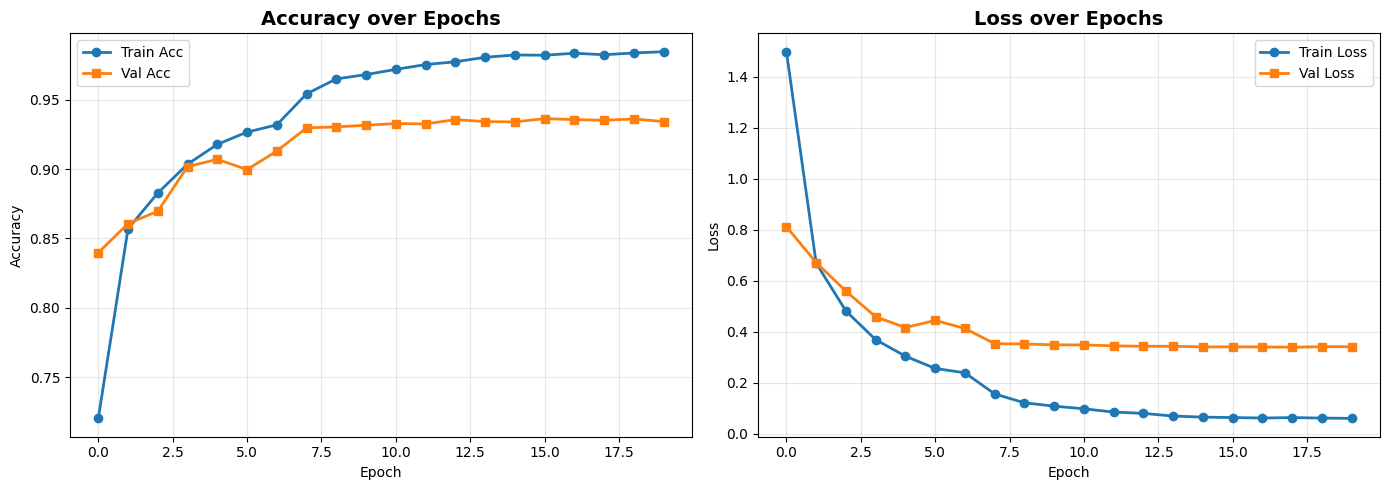

In [17]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
plt.title('Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
plt.show()

In [ ]:
model_trained = models.resnet18(weights=None)

num_ftrs = model_trained.fc.in_features
model_trained.fc = nn.Sequential(
    nn.Dropout(0.3),              
    nn.Linear(num_ftrs, 256),
    nn.BatchNorm1d(256),          
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),              
    nn.Linear(256, NUM_CLASSES)
)
model_trained = model_trained.to(device)
model_trained.load_state_dict(torch.load('simpsons_classifier.pth', weights_only=True))
model_trained.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_trained(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\nМЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")


МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Accuracy:  0.9596
   Precision: 0.9699
   Recall:    0.9596
   F1-Score:  0.9644


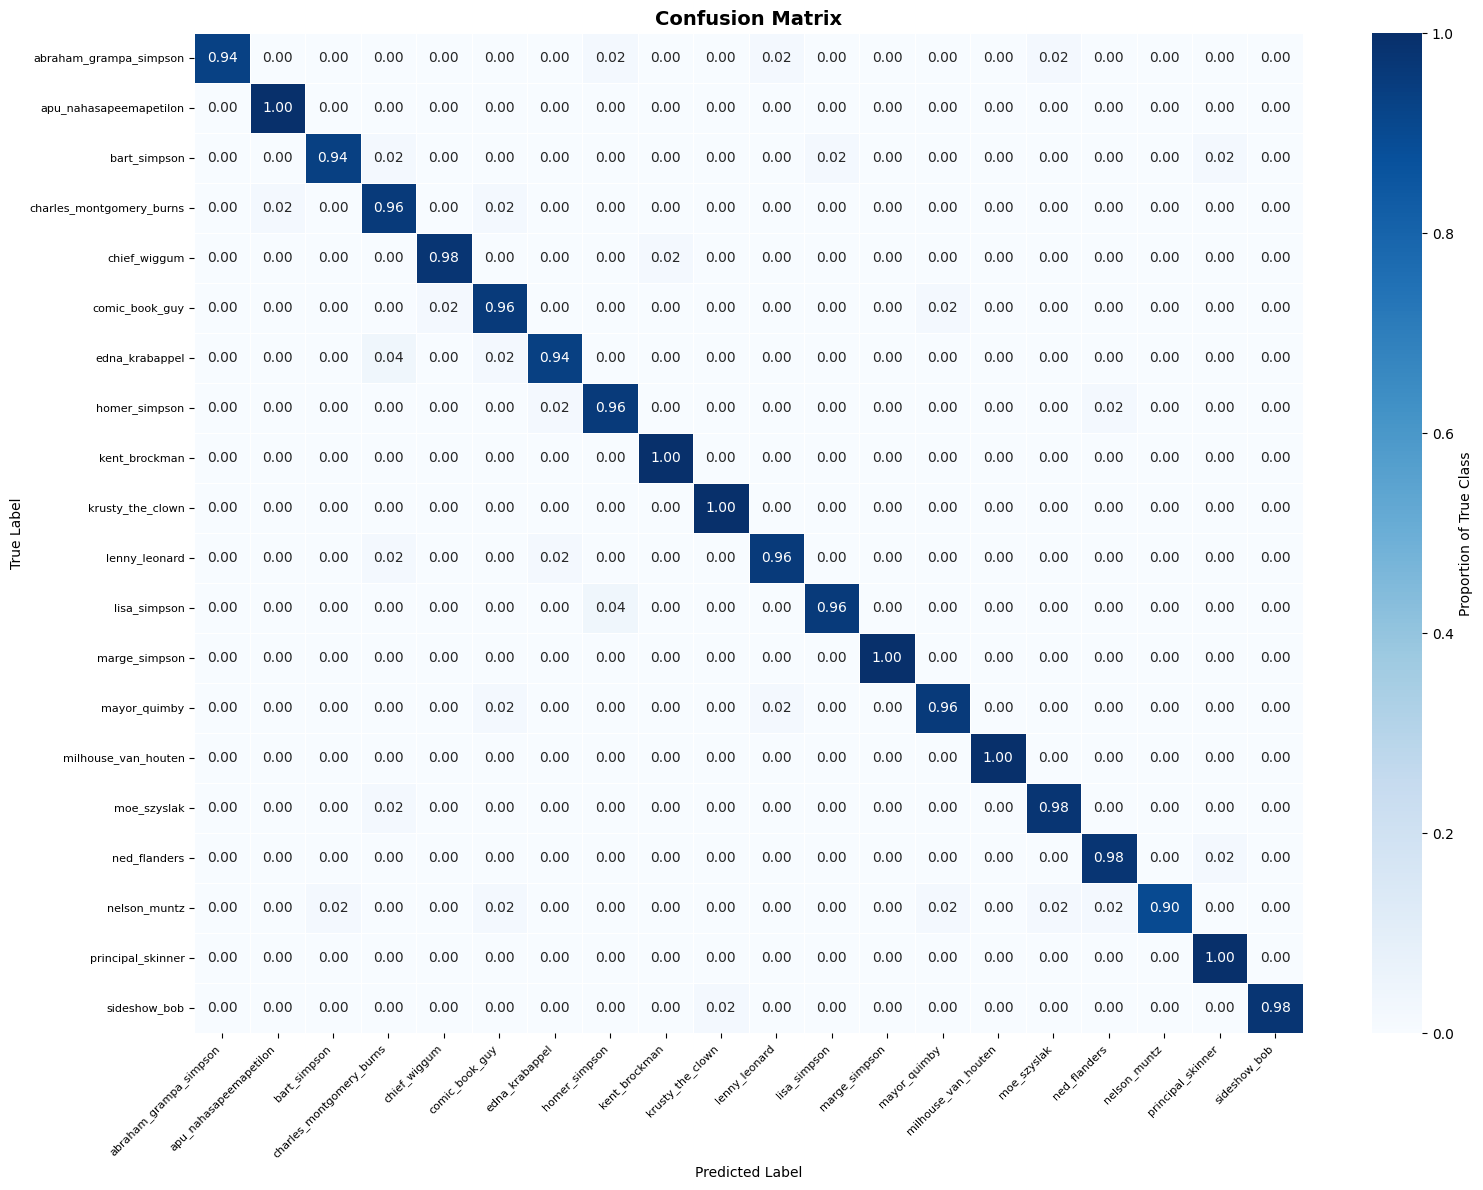

In [19]:
true_labels_set = set(all_labels)

pred_only_classes = set(all_preds) - true_labels_set

active_classes = sorted(true_labels_set)
active_class_names = [class_names_final[i] for i in active_classes]

cm_active = confusion_matrix(
    all_labels, all_preds, 
    labels=active_classes
)

row_sums = cm_active.sum(axis=1, keepdims=True)

row_sums[row_sums == 0] = 1
cm_norm = cm_active.astype('float') / row_sums
cm_norm = np.nan_to_num(cm_norm, 0)

n_classes = len(active_classes)
fig_height = max(8, n_classes * 0.6)
fig_width = max(10, n_classes * 0.8)
plt.figure(figsize=(fig_width, fig_height))
fontsize = max(6, min(10, 12 - n_classes // 5))

sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=active_class_names,
    yticklabels=active_class_names,
    cbar_kws={'label': 'Proportion of True Class'},
    linewidths=0.5
)

plt.title(f'Confusion Matrix', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=fontsize)
plt.yticks(rotation=0, fontsize=fontsize)
plt.tight_layout()
plt.savefig('confusion_matrix_clean.png', dpi=300, bbox_inches='tight')
plt.show()

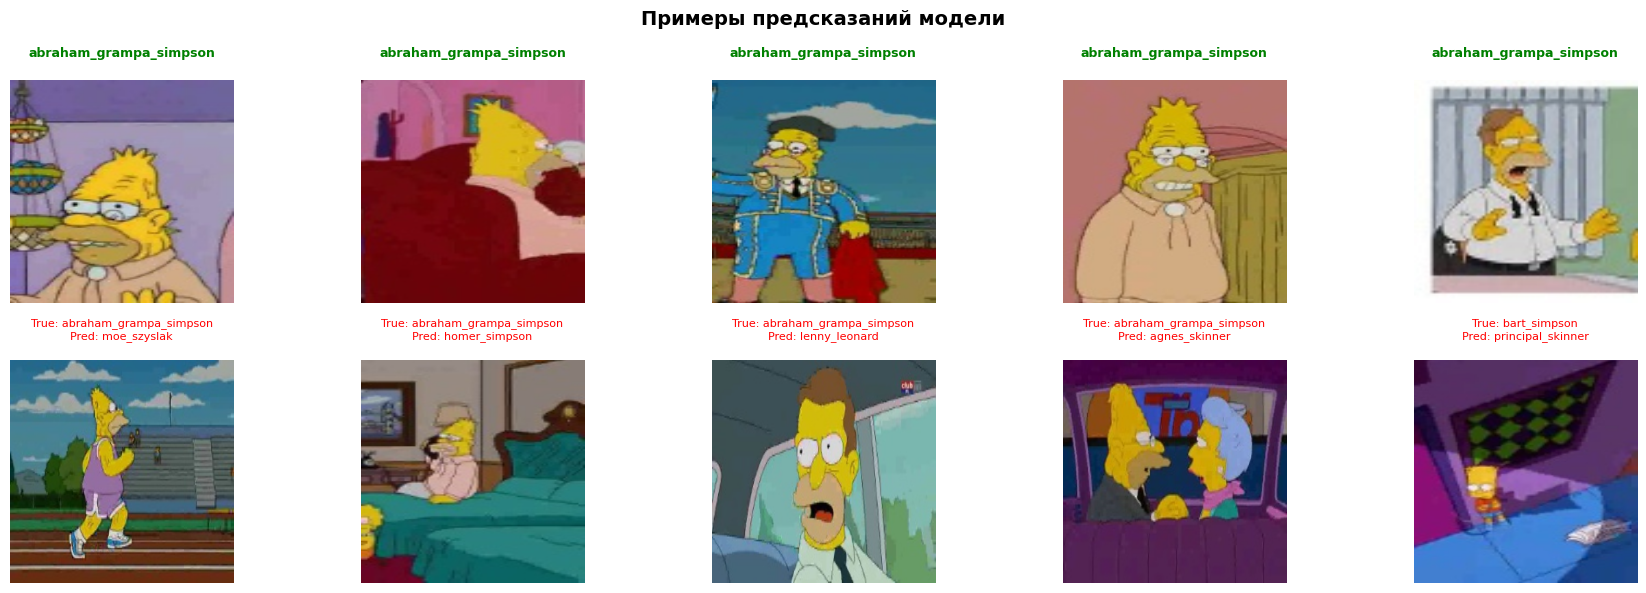

In [20]:
def denormalize(img):
    mean = torch.tensor(IMAGE_NET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGE_NET_STD).view(3, 1, 1)
    return img * std + mean

correct_examples = []
incorrect_examples = []

model_trained.eval()

with torch.no_grad():
    for inputs, labels in test_loader: 
        inputs_device = inputs.to(device)
        outputs = model_trained(inputs_device)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(labels)):
            if labels[i] == preds[i] and len(correct_examples) < 5:
                correct_examples.append((
                    inputs[i].cpu(),           
                    labels[i].item(),          
                ))
            elif labels[i] != preds[i] and len(incorrect_examples) < 5:
                incorrect_examples.append((
                    inputs[i].cpu(),           
                    labels[i].item(),          
                    preds[i].item(),          
                ))
        
        if len(correct_examples) >= 5 and len(incorrect_examples) >= 5:
            break


fig, axes = plt.subplots(2, 5, figsize=(18, 6))


for idx, (img, label) in enumerate(correct_examples):
    ax = axes[0, idx]
    img_denorm = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_denorm)
    ax.set_title(f"{class_names_final[label]}\n", 
                color='green', fontsize=9, fontweight='bold')
    ax.axis('off')

for idx, (img, true_label, pred_label) in enumerate(incorrect_examples):
    ax = axes[1, idx]
    img_denorm = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_denorm)
    ax.set_title(f"True: {class_names_final[true_label]}\nPred: {class_names_final[pred_label]}\n", 
                color='red', fontsize=8)
    ax.axis('off')
    
plt.suptitle('Примеры предсказаний модели', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_examples.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
torch.save(model_trained.state_dict(), 'simpsons_classifier2.pth')

results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'num_classes': NUM_CLASSES,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE
}
pd.DataFrame([results]).to_csv('metrics_summary2.csv', index=False)
pd.DataFrame(history).to_csv('training_history2.csv', index=False)